# Analysis
**ANALYSIS & ANALYTICS**

---

**Zweck:** Städte-Ranking und die drei Indikator-Kandidaten (kategorisch, Integer, Float) bewerten, Grenzwerte bestimmen.
**Input:** `data/processed/telco_churn_clean.csv` (aus `02_preparation`).
**Output:** Top-4-Städte, drei Kontakt-Schwellenwerte + betroffene Kundenzahlen — Basis für `04_insights`.

## Inhalt

- [Business Case](#business-case)
- [City Ranking: Top-4 Churn Districts](#city-ranking-top-4-churn-districts)
- [Categorical Indicator: International Plan](#categorical-indicator-international-plan)
- [Integer Indicator: Customer Service Calls](#integer-indicator-customer-service-calls)
- [Float Indicator: Total Day Minutes + Logistic Regression](#float-indicator-total-day-minutes--logistic-regression)
- [Summary: Indicators for Individual Contact](#summary-indicators-for-individual-contact)

## Business Case

Vier Fragen aus `00_introduction` werden hier beantwortet:

1. Welche 4 Stadtgebiete haben die hoechste Kundenabwanderung? (Plakatkampagne)
2. Welche kategorische Variable eignet sich als Indikator fuer Individualkontakt?
3. Welche Integer-Variable eignet sich, und wo liegt der Grenzwert?
4. Welche Float-Variable eignet sich, und wo liegt der per Logistic Regression bestimmte Grenzwert?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from pathlib import Path

DATA_PROCESSED = Path('../data/processed')
df_clean = pd.read_csv(DATA_PROCESSED / 'telco_churn_clean.csv')
df_clean.head()

,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,customer_service_calls,churn,phone_num,city,area_code
0,131,0,0,0,187.9,110,31.94,200.5,101,17.04,202.6,125,9.12,2,0,1473,Tallahassee,850.0
1,63,1,1,21,151.5,99,25.76,147.8,89,12.56,210.4,114,9.47,1,0,8029,Miami2,786.0
2,13,0,0,0,303.2,133,51.54,170.5,86,14.49,227.6,80,10.24,0,1,7468,Jacksonville,904.0
3,129,0,0,0,159.1,100,27.05,202.5,90,17.21,233.1,96,10.49,2,0,4979,Miami1,305.0
4,120,0,1,28,215.8,123,36.69,285.2,76,24.24,192.1,78,8.64,1,0,9620,Cape Coral,239.0


## City Ranking: Top-4 Churn Districts

> _Basis fuer die Plakatkampagne._

,total_customers,churn_cnt_0,churn_pct_0,churn_cnt_1,churn_pct_1,churn_pct_total
city,,,,,,
Jacksonville,332,233,70.18,99,29.82,20.50
Orlando1,300,229,76.33,71,23.67,14.70
Cape Coral,303,237,78.22,66,21.78,13.66
Orlando2,304,246,80.92,58,19.08,12.01


Total churn count: 483
Jacksonville: 99.0 churned, 29.82% rate
Orlando1: 71.0 churned, 23.67% rate
Cape Coral: 66.0 churned, 21.78% rate
Orlando2: 58.0 churned, 19.08% rate

The top-4 cities account for 60.9% of all churn.


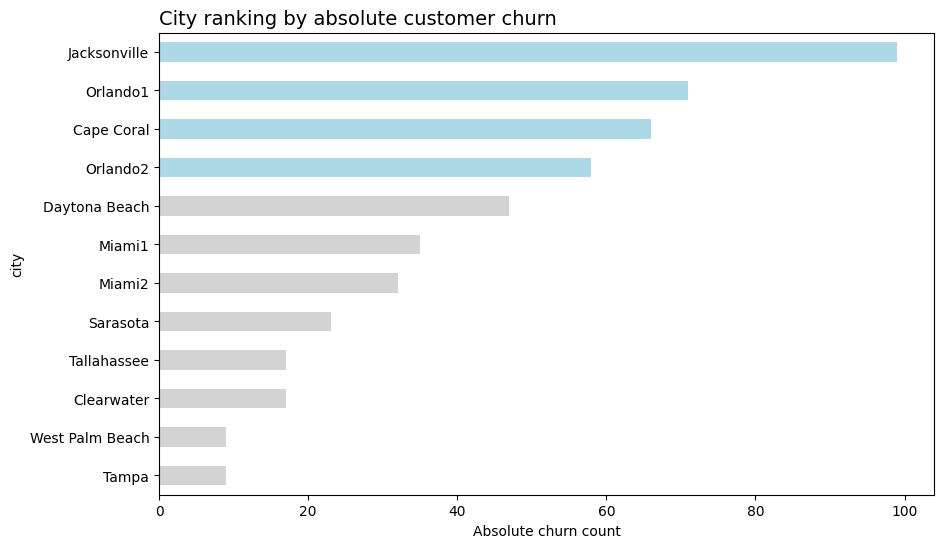

In [2]:
churn_city_counts = pd.crosstab(df_clean['city'], df_clean['churn'])
churn_city_percents = round(pd.crosstab(df_clean['city'], df_clean['churn'], normalize='index') * 100, 2)
churn_total_count = churn_city_counts[1].sum()

churn_city_summary = pd.DataFrame({
    'total_customers': churn_city_counts[0] + churn_city_counts[1],
    'churn_cnt_0': churn_city_counts[0],
    'churn_pct_0': churn_city_percents[0],
    'churn_cnt_1': churn_city_counts[1],
    'churn_pct_1': churn_city_percents[1],
    'churn_pct_total': round(churn_city_counts[1] * 100 / churn_total_count, 2),
})
churn_city_summary.sort_values(by='churn_cnt_1', ascending=False, inplace=True)

top4_city_churn_ranking = churn_city_summary.head(4)
display(top4_city_churn_ranking)

print(f"Total churn count: {churn_total_count}")
for city, row in top4_city_churn_ranking.iterrows():
    print(f"{city}: {row['churn_cnt_1']} churned, {row['churn_pct_1']}% rate")
print(f"\nThe top-4 cities account for {top4_city_churn_ranking['churn_pct_total'].sum():.1f}% of all churn.")

data = churn_city_summary['churn_cnt_1'].sort_values(ascending=True)
colors = ['lightgray'] * (len(data) - 4) + ['lightblue'] * 4
ax = data.plot(kind='barh', color=colors, figsize=(10, 6))
ax.set_title('City ranking by absolute customer churn', loc='left', fontsize=14)
ax.set_xlabel('Absolute churn count')
plt.show()

## Categorical Indicator: International Plan

> _Basis fuer Aufgabe 4a — Individualkontakt._

voice_mail_plan:


churn,0,1
voice_mail_plan,,
0,0.832849,0.167151
1,0.913232,0.086768


international_plan:


churn,0,1
international_plan,,
0,0.885050,0.114950
1,0.575851,0.424149


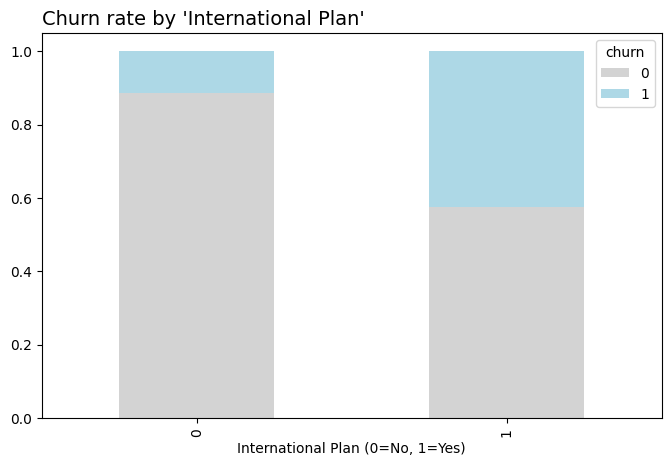

Customers affected for individual contact: 323


In [3]:
# Check both categorical candidates
for col in ['voice_mail_plan', 'international_plan']:
    ct = pd.crosstab(df_clean[col], df_clean['churn'], normalize='index')
    print(f"{col}:")
    display(ct)

# voice_mail_plan: not an indicator of churn (rather associated with retention)
# international_plan: clearly higher churn share -> strong signal
ct_intplan_churn = pd.crosstab(df_clean['international_plan'], df_clean['churn'], normalize='index')

ax = ct_intplan_churn.plot(kind='bar', stacked=True, color=['lightgray', 'lightblue'], figsize=(8, 5))
ax.set_title("Churn rate by 'International Plan'", loc='left', fontsize=14)
ax.set_xlabel('International Plan (0=No, 1=Yes)')
plt.show()

mask = df_clean['international_plan'] == 1
international_plan_customers = df_clean.loc[mask, 'phone_num']
print(f"Customers affected for individual contact: {international_plan_customers.shape[0]}")

## Integer Indicator: Customer Service Calls

> _Basis fuer Aufgabe 4b — Grenzwert per Korrelation + Verlauf._

churn                     1.000000
customer_service_calls    0.205827
total_day_calls           0.020325
account_length            0.016541
total_eve_calls           0.008153
total_night_calls         0.007257
number_vmail_messages    -0.089728
Name: churn, dtype: float64


,customer_service_calls,churn
0,0,0.134877
1,1,0.101724
2,2,0.113055
3,3,0.102564
4,4,0.457831
5,5,0.606061
6,6,0.636364
7,7,0.555556
8,8,0.500000
9,9,1.000000


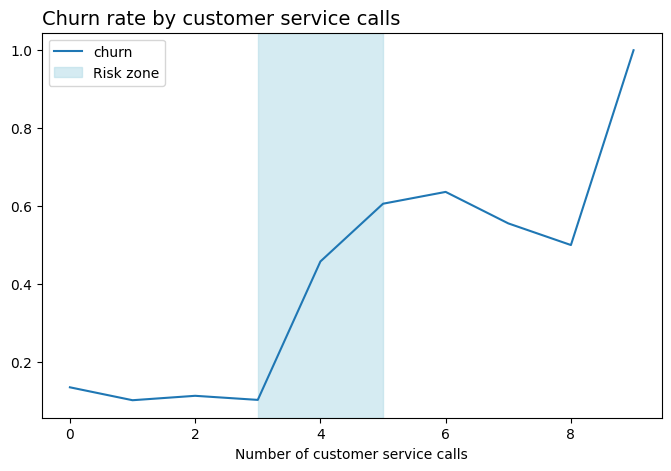

Customers affected (threshold >= 3 calls): 696


In [4]:
int_cols = ['account_length', 'number_vmail_messages', 'total_day_calls',
            'total_eve_calls', 'total_night_calls', 'customer_service_calls']

churn_int_corr = df_clean[int_cols + ['churn']].corr()
print(churn_int_corr['churn'].sort_values(ascending=False))
# customer_service_calls shows the strongest correlation with churn

csc_churn_rate = df_clean.groupby('customer_service_calls')['churn'].mean().reset_index()
display(csc_churn_rate)

ax = csc_churn_rate['churn'].plot(figsize=(8, 5))
ax.axvspan(3, 5, color='lightblue', alpha=0.5, label='Risk zone')
ax.set_title('Churn rate by customer service calls', loc='left', fontsize=14)
ax.set_xlabel('Number of customer service calls')
ax.legend()
plt.show()

# Churn rate jumps sharply starting at 4 calls -> contact threshold at 3 (early warning)
mask = df_clean['customer_service_calls'] >= 3
csc_risk_customers = df_clean.loc[mask, 'phone_num']
print(f"Customers affected (threshold >= 3 calls): {csc_risk_customers.shape[0]}")

## Float Indicator: Total Day Minutes + Logistic Regression

> _Basis fuer Aufgabe 4c — Grenzwert per logistischer Regression (50%-Schwelle)._

churn                  1.000000
total_day_minutes      0.206240
total_day_charge       0.205151
total_eve_minutes      0.092796
total_eve_charge       0.092786
total_night_charge     0.035496
total_night_minutes    0.035493
Name: churn, dtype: float64


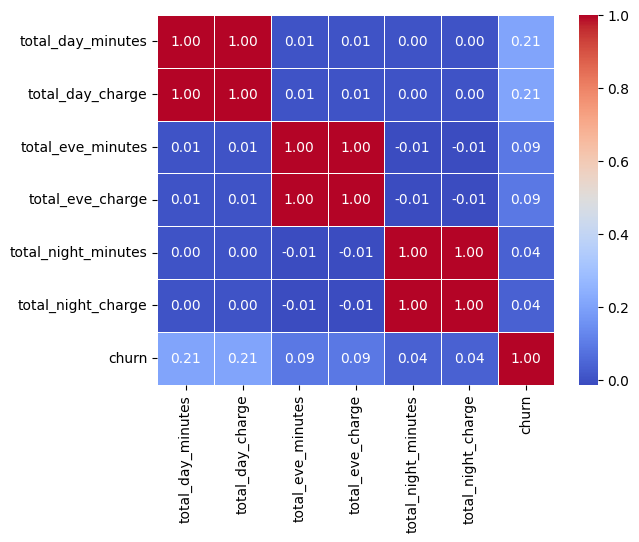

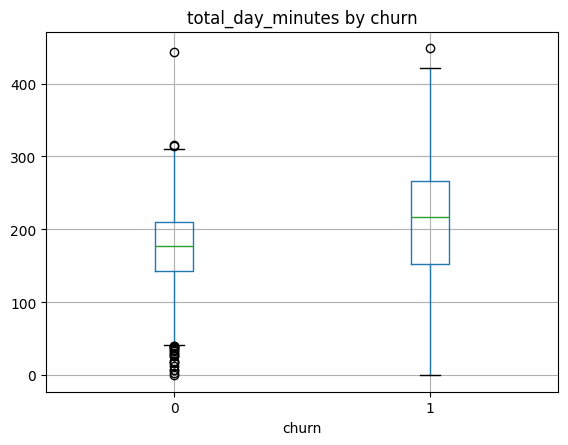

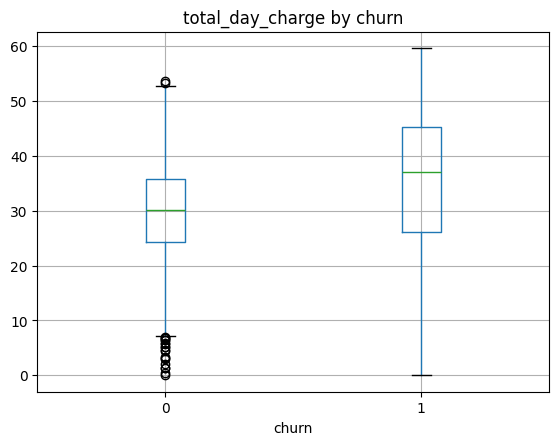

Optimization terminated successfully.
         Current function value: 0.392146
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 3333
Model:                          Logit   Df Residuals:                     3331
Method:                           MLE   Df Model:                            1
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                 0.05230
Time:                        13:19:51   Log-Likelihood:                -1307.0
converged:                       True   LL-Null:                       -1379.1
Covariance Type:            nonrobust   LLR p-value:                 3.138e-33
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -3.9023      0.200    -19.465      0.000      -4.295      -3.509
total_da

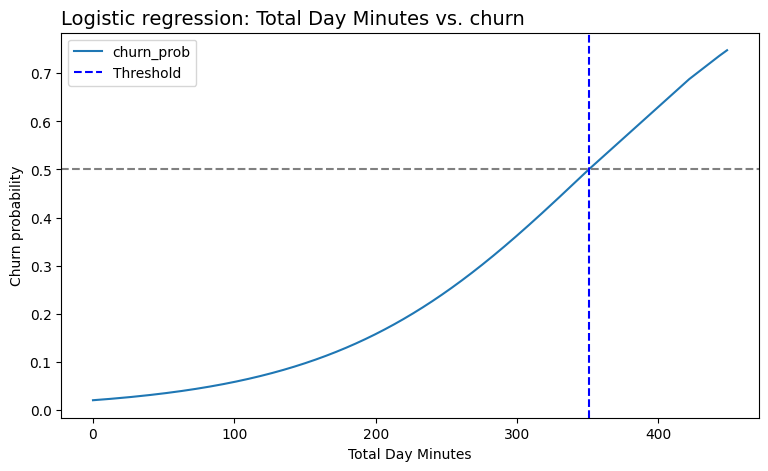

Customers affected (>= 351 minutes): 4


In [5]:
float_cols = ['total_day_minutes', 'total_day_charge', 'total_eve_minutes',
              'total_eve_charge', 'total_night_minutes', 'total_night_charge']

churn_float_corr = df_clean[float_cols + ['churn']].corr()
print(churn_float_corr['churn'].sort_values(ascending=False))
# total_day_charge and total_day_minutes correlate most strongly with churn and are
# almost identical to each other (charge is a function of minutes) -> we use total_day_minutes

sns.heatmap(churn_float_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

for fc in float_cols[:2]:
    df_clean.boxplot(column=fc, by='churn')
    plt.title(f'{fc} by churn')
    plt.suptitle('')
    plt.show()

# Logistic regression: total_day_minutes (X) -> churn (Y)
model = smf.logit(formula='churn ~ total_day_minutes', data=df_clean)
result = model.fit()
print(result.summary())

intercept = result.params['Intercept']
coef = result.params['total_day_minutes']

# Threshold at 50% churn probability
threshold = -intercept / coef
print(f"\nThreshold (50% churn probability): {threshold:.2f} minutes")

tdm_plot_df = df_clean[['total_day_minutes']].copy().sort_values('total_day_minutes')
tdm_plot_df['churn_prob'] = 1 / (1 + np.exp(-(intercept + coef * tdm_plot_df['total_day_minutes'])))

ax = tdm_plot_df.plot(x='total_day_minutes', y='churn_prob', kind='line', figsize=(9, 5))
ax.axvline(threshold, color='blue', linestyle='--', label='Threshold')
ax.axhline(0.5, color='gray', linestyle='--')
ax.set_xlabel('Total Day Minutes')
ax.set_ylabel('Churn probability')
ax.set_title('Logistic regression: Total Day Minutes vs. churn', loc='left', fontsize=14)
ax.legend()
plt.show()

mask = df_clean['total_day_minutes'] >= threshold
tdm_risk_customers = df_clean.loc[mask, 'phone_num']
print(f"Customers affected (>= {threshold:.0f} minutes): {tdm_risk_customers.shape[0]}")

## Summary: Indicators for Individual Contact

> _Konsolidierung der drei Kandidaten fuer die Empfehlungen in `04_insights`._

In [6]:
indicator_summary = pd.DataFrame({
    'indicator': ['international_plan == 1', 'customer_service_calls >= 3', f'total_day_minutes >= {threshold:.0f}'],
    'customers_affected': [
        international_plan_customers.shape[0],
        csc_risk_customers.shape[0],
        tdm_risk_customers.shape[0],
    ],
})
display(indicator_summary)

# Overlap: customers matching multiple indicators (highest priority)
mask_any = (
    (df_clean['international_plan'] == 1)
    | (df_clean['customer_service_calls'] >= 3)
    | (df_clean['total_day_minutes'] >= threshold)
)
print(f"Customers with at least one risk indicator: {mask_any.sum()} of {df_clean.shape[0]}")

,indicator,customers_affected
0,international_plan == 1,323
1,customer_service_calls >= 3,696
2,total_day_minutes >= 351,4


Customers with at least one risk indicator: 954 of 3333
